In [1]:
# General imports 
import os 
import numpy as np
import pandas as pd
from pathlib import Path
import scipy.stats as stats 
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# PyNWB imports
from hdmf_zarr import NWBZarrIO

# # Util imports 
from utils.filter_roi_table import filter_roi_table, filter_dff

In [2]:
metadata = pd.read_csv(os.path.join('/data/', 'metadata', 'bci_metadata.csv'))
metadata.head()

,project_name,session_type,_id,name,subject_id,genotype,virus,date_of_birth,sex,modality,session_date,age,session_time,targeted_structure,ophys_fov,session_number
0,Brain Computer Interface,BCI single neuron stim,b8827d25-495f-46a8-9f33-ffb24da527a5,single-plane-ophys_731015_2025-01-10_18-06-31_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-10,302,16:46:51.981999,Primary Motor Cortex,FOV_04,18.0
1,Brain Computer Interface,BCI single neuron stim,127a3e78-729c-4df7-bf34-1b9308939587,single-plane-ophys_731015_2025-01-24_20-00-44_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-24,316,18:41:22.550000,Primary Motor Cortex,FOV_04,20.0
2,Brain Computer Interface,BCI single neuron stim,0162d41c-613c-4215-b0aa-9690f85a9fda,single-plane-ophys_731015_2025-01-28_18-56-35_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-28,320,17:40:57.996000,Primary Motor Cortex,FOV_04,22.0
3,Brain Computer Interface,BCI single neuron stim,b9a4c361-66b0-4cd5-9392-75d116ef3385,single-plane-ophys_731015_2025-01-31_20-37-19_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-31,323,20:37:19.623000,Primary Motor Cortex,FOV_04,23.0
4,Brain Computer Interface,BCI single neuron stim,30006aee-36db-44d9-a1fb-1b6583619434,single-plane-ophys_740369_2025-01-09_17-18-37_...,740369,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-05-03,Female,Planar optical physiology,2025-01-09,251,16:01:04.455000,Primary Motor Cortex,FOV_05,22.0


In [3]:
metadata.value_counts(['subject_id'])

subject_id
740369        5
767715        5
754303        5
731015        4
766719        3
Name: count, dtype: int64

In [4]:
metadata[['name', 'subject_id', 'ophys_fov', 'session_number']].head()

,name,subject_id,ophys_fov,session_number
0,single-plane-ophys_731015_2025-01-10_18-06-31_...,731015,FOV_04,18.0
1,single-plane-ophys_731015_2025-01-24_20-00-44_...,731015,FOV_04,20.0
2,single-plane-ophys_731015_2025-01-28_18-56-35_...,731015,FOV_04,22.0
3,single-plane-ophys_731015_2025-01-31_20-37-19_...,731015,FOV_04,23.0
4,single-plane-ophys_740369_2025-01-09_17-18-37_...,740369,FOV_05,22.0


In [5]:
metadata[['genotype', 'virus', 'targeted_structure']].value_counts()


genotype                                                                                  virus                                            targeted_structure  
Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-ICL-ChRmine-oScarlet-IRES2-tTA2-WPRE)-hyg/wt  pAAV-hSyn1-RiboL1-GCaMP8s-WPRE                   Primary Motor Cortex    14
Camk2a-tTA/wt;TetO-jGCaMP8s-01/wt                                                         pAAV-CaMKIIa-ChRmine-oScarlet-Kv2.1-WPRE - 7413  Primary Motor Cortex     8
Name: count, dtype: int64

In [6]:
# Select a mouse 
subject_id = 767715

# Look at its metadata, sorted by 'session_number'
this_mouse_metadata = metadata[metadata['subject_id']==subject_id].sort_values(by='session_number')
this_mouse_metadata


,project_name,session_type,_id,name,subject_id,genotype,virus,date_of_birth,sex,modality,session_date,age,session_time,targeted_structure,ophys_fov,session_number
17,Brain Computer Interface,BCI single neuron stim,c7470968-816b-49ae-9ebd-b4579e458cb4,single-plane-ophys_767715_2025-01-31_18-15-21_...,767715,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-09-15,Female,Planar optical physiology,2025-01-31,138,18:15:21.158999,Primary Motor Cortex,FOV_01,2.0
18,Brain Computer Interface,BCI single neuron stim,81b6cb9b-5885-4b29-8354-5d44065fc5a7,single-plane-ophys_767715_2025-02-03_17-30-05_...,767715,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-09-15,Female,Planar optical physiology,2025-02-03,141,17:30:05.458999,Primary Motor Cortex,FOV_02,3.0
19,Brain Computer Interface,BCI single neuron stim,3788a435-4e4d-42b7-8718-44cd9c43b6b7,single-plane-ophys_767715_2025-02-06_18-59-24_...,767715,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-09-15,Female,Planar optical physiology,2025-02-06,144,18:59:24.815999,Primary Motor Cortex,FOV_01,4.0
20,Brain Computer Interface,BCI single neuron stim,3a82e844-4bd9-4f0e-a017-56419a967c79,single-plane-ophys_767715_2025-02-10_16-04-20_...,767715,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-09-15,Female,Planar optical physiology,2025-02-10,148,16:04:20.109000,Primary Motor Cortex,FOV_03,5.0
21,Brain Computer Interface,BCI single neuron stim,b28d6321-1b1b-4110-87fb-0e19325c1dfe,single-plane-ophys_767715_2025-02-17_17-41-50_...,767715,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-09-15,Female,Planar optical physiology,2025-02-17,155,17:41:50.758000,Primary Motor Cortex,FOV_03,8.0


In [7]:
# Select a session for this mouse 
session_name = this_mouse_metadata.name.values[2]
print('Selected session is', session_name)


Selected session is single-plane-ophys_767715_2025-02-06_18-59-24_processed_2025-08-06_19-25-46


In [8]:
# Get the directory for this dataset
session_dir = os.path.join('/data/', 'brain-computer-interface-v2', session_name)

# Now find the NWB file and set the path to load it
nwb_file = [file for file in os.listdir(session_dir) if 'nwb' in file][0]
nwb_path = os.path.join(session_dir, nwb_file)
print(nwb_path)


/data/brain-computer-interface-v2/single-plane-ophys_767715_2025-02-06_18-59-24_processed_2025-08-06_19-25-46/single-plane-ophys_767715_2025-02-06_18-59-24_behavior_nwb


In [9]:
with NWBZarrIO(str(nwb_path), 'r') as io:
    nwbfile = io.read()
    print('Loaded NWB file from:', nwb_path)
    
nwbfile


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Loaded NWB file from: /data/brain-computer-interface-v2/single-plane-ophys_767715_2025-02-06_18-59-24_processed_2025-08-06_19-25-46/single-plane-ophys_767715_2025-02-06_18-59-24_behavior_nwb


root pynwb.file.NWBFile at 0x139918824144704
Fields:
  devices: {
    442_Bergamo_2p_photostim <class 'pynwb.device.Device'>
  }
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2025, 8, 6, 13, 22, 17, 586817, tzinfo=tzutc())]
  identifier: 54631d7e-4f2d-4e41-b2ab-9ee7e2a4899c
  imaging_planes: {
    processed <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>
  }
  processing: {
    processed <class 'pynwb.base.ProcessingModule'>
  }
  session_description: NWB file generated by AIND pipeline
  session_id: single-plane-ophys_767715_2025-02-06_18-59-24
  session_start_time: 2025-02-06 18:59:24-08:00
  stimulus: {
    PhotostimTrials <class 'hdmf.common.table.DynamicTable'>,
    Trials <class 'hdmf.common.table.DynamicTable'>
  }
  subject: subject pynwb.file.Subject at 0x139918822907504
Fields:
  age: P144D
  age__reference: birth
  date_of_birth: 2024-09-15 00:00:00-07:53
  genotype: Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-ICL-ChRmine-oScarlet-IRES2-tTA2-WPRE)-hyg/wt
  sex: F
  species: Mus musculus
  subject_id: 767715

  timestamps_reference_time: 2025-02-06 18:59:24-08:00

Text(0.5, 1.0, 'Average Projection of Session Imaging Frames')

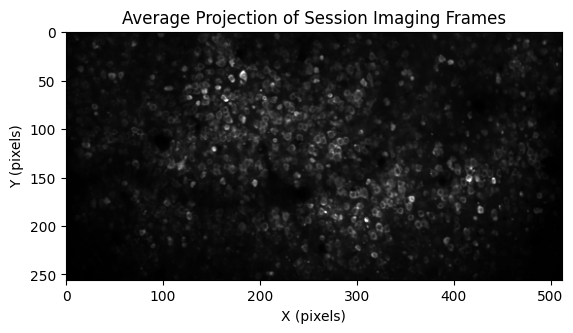

In [10]:
avg_projection = nwbfile.processing["processed"].data_interfaces["images"].images["average_projection"]
plt.imshow(avg_projection, 
           cmap="gray", 
           origin='upper', 
           aspect='equal', 
           vmax=0.7)
plt.xlabel('X (pixels)') 
plt.ylabel('Y (pixels)')
plt.title('Average Projection of Session Imaging Frames') 

In [11]:
image_segmentation = nwbfile.processing["processed"].data_interfaces["image_segmentation"].plane_segmentations["roi_table"].to_dataframe()
image_segmentation


,is_soma,soma_probability,is_dendrite,dendrite_probability,image_mask
id,,,,,
0,1,0.998733,0,0.000000e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,0,0.001767,0,5.960464e-08,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1,0.605445,0,0.000000e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,0,0.091949,0,0.000000e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1,0.999846,0,0.000000e+00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...
2226,0,0.000000,0,4.172325e-07,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2227,0,0.000000,0,1.013279e-06,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2228,0,0.000000,1,9.392629e-01,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


Text(0.5, 1.0, 'ROI Image Mask')

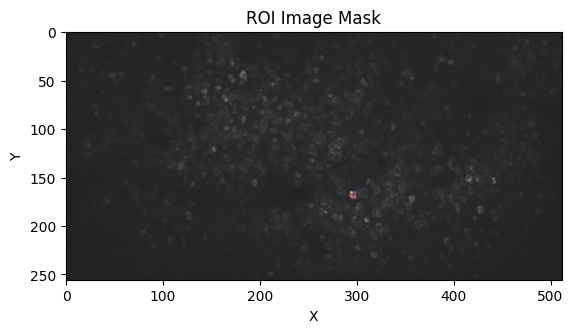

In [12]:
# Plot the image mask overlaid with the average projection image
ROI = 1

avg_projection = (
    nwbfile.processing["processed"]
    .data_interfaces["images"]
    .images["average_projection"]
)

plt.imshow(image_segmentation.image_mask[ROI], 
           alpha = 0.8, 
           cmap = "inferno")

plt.imshow(avg_projection, 
           cmap="gray", 
           alpha = 0.3, 
           origin='upper', 
           aspect='equal', 
           vmax=0.7)
plt.xlabel('X') 
plt.ylabel('Y') 
plt.title('ROI Image Mask') 


In [13]:
# Get dff array (neurons x frames time-series array of neural activity) and frame rate from nwb file 
dff = nwbfile.processing["processed"].data_interfaces["dff"].roi_response_series["dff"].data
print('dff shape:',np.shape(dff))


dff shape: (216866, 2231)


In [14]:
#get imaging frame rate from the NWB file in Hz
frame_rate = nwbfile.imaging_planes["processed"].imaging_rate

#convert to seconds
time_step = 1/frame_rate

#create equally spaced timestamps array
n_frames = dff.shape[0]
timestamps = np.linspace(0, (time_step*n_frames), num=n_frames)


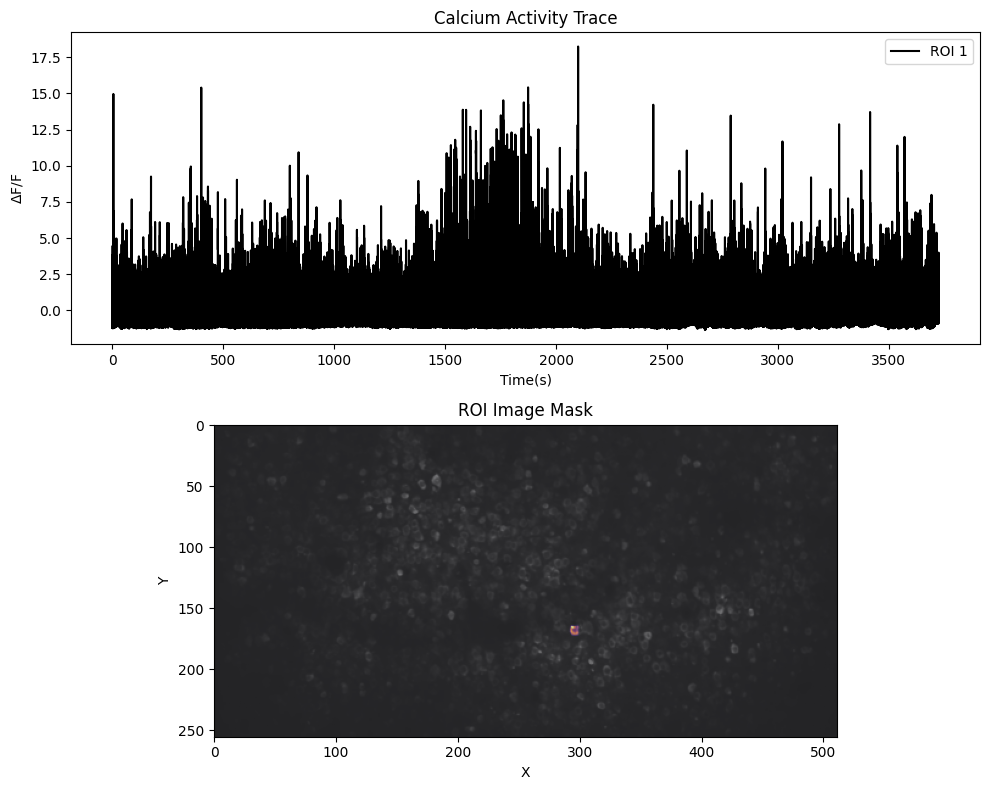

In [15]:
# Plot dff array and ROI contours 

plt.figure(figsize=(10, 8))

# Plot ROI dff 
plt.subplot(2, 1, 1)
plt.plot(timestamps, dff[:, ROI], 
         label=f'ROI {ROI}', 
         color='black')
plt.ylabel(r'$\Delta$F/F')
plt.xlabel('Time(s)')
plt.title('Calcium Activity Trace')
plt.legend(bbox_to_anchor=(1.0, 1.0))


# Plot ROI image mask
plt.subplot(2, 1, 2)

plt.imshow(image_segmentation.image_mask[ROI],
           alpha=0.8,
           cmap="inferno")

plt.imshow(avg_projection, 
           cmap="gray", 
           origin='upper', 
           aspect='equal', 
           alpha=0.3, 
           vmax=0.7)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('ROI Image Mask')

plt.tight_layout()
plt.show()


In [16]:
# Load the epochs table from the NWB file
epoch_table = nwbfile.intervals["epochs"].to_dataframe()
epoch_table


,stimulus_name,start_frame,stop_frame,start_time,stop_time
id,,,,,
0,photostim,0,73393,0.000000,1260.601918
1,spont,73394,80593,1260.619094,1384.269485
2,spont_01,80594,87004,1384.286661,1494.385149
3,BCI,87005,127899,1494.402325,2196.799758
4,spont_post,127900,141699,2196.816934,2433.829263
5,photostim_post,141700,216865,2433.846439,3724.884319


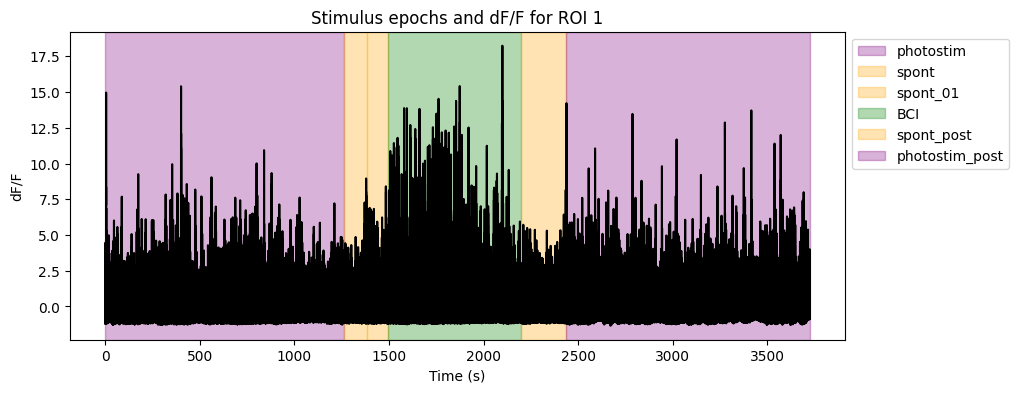

In [17]:
# Set up figure
plt.figure(figsize=(10, 4))

# Plot dff trace
plt.plot(timestamps, dff[:, ROI], color="black")

# Get epoch info
epoch_table = nwbfile.intervals["epochs"].to_dataframe()
stimulus_names = epoch_table.stimulus_name.unique()

# Define fixed colors
color_map = {
    "spont": "orange",
    "photostim": "purple",
    "other": "green"
}

# Plot shaded blocks for each stimulus epoch
for stimulus_name in stimulus_names:
    stim_epoch = epoch_table[epoch_table.stimulus_name == stimulus_name]

    # Assign color based on name
    lname = stimulus_name.lower()
    if "spont" in lname:
        color = color_map["spont"] # All spontaneous epochs == orange
    elif "photostim" in lname:
        color = color_map["photostim"] # All photostim epochs == purple
    else:
        color = color_map["other"] # Other (BCI) == green

    plt.axvspan(stim_epoch.start_time.values[0], stim_epoch.stop_time.values[0], color=color, alpha=0.3, label=stimulus_name)

# Labels and title
plt.ylabel("dF/F")
plt.xlabel("Time (s)")
plt.title(f"Stimulus epochs and dF/F for ROI {ROI}")
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()


In [18]:
# Available stimulus tables
nwbfile.stimulus.keys()


dict_keys(['PhotostimTrials', 'Trials'])

In [19]:
# Load the BCI trials table
trials = nwbfile.stimulus["Trials"].to_dataframe()
trials.head()


,start_time,stop_time,go_cue,hit,lick_L,reward_time,threshold_crossing_times,zaber_step_times,tiff_file,start_frame,stop_frame,conditioned_neuron_x,conditioned_neuron_y,closest_roi
id,,,,,,,,,,,,,,
0,1495.547992,1501.718922,0.2359,True,"[2.3583000000000003, 2.5055, 2.680900000000000...",2.5055,2.3603,"[1.7129, 1.7969000000000002, 1.8479, 1.9209, 1...",neuron7_00001.tif,87005,87364,294.333333,203.907407,2
1,1501.736111,1511.585534,0.2359,True,"[5.0208, 5.6304, 5.9318, 6.0777, 6.1902, 6.317...",6.1902,6.0780,"[1.9485, 2.1175, 2.2875, 4.7073, 4.7723, 4.814...",neuron7_00002.tif,87365,87938,294.333333,203.907407,2
2,1511.602723,1521.813119,0.2359,True,"[5.084700000000001, 5.301200000000001, 5.4957,...",5.6866,5.5003,"[1.2776, 1.4006, 1.5266000000000002, 1.6615, 3...",neuron7_00003.tif,87939,88533,294.333333,203.907407,2
3,1521.830308,1530.562431,0.2359,True,"[4.3437, 4.545100000000001, 4.7372000000000005...",4.7372,4.7194,"[1.7653, 1.8653, 1.9463, 2.0053, 2.0493, 2.089...",neuron7_00004.tif,88534,89042,294.333333,203.907407,2
4,1530.579620,1536.355198,0.2359,True,"[2.1197, 2.2427, 2.2821, 2.3767, 2.5104, 2.649...",2.1197,2.0803,"[0.2866, 0.4466, 1.6495000000000002, 1.7175, 1...",neuron7_00005.tif,89043,89379,294.333333,203.907407,2


In [20]:
print(f"Conditioned Neuron Index (in original unfiltered dff array): {trials.closest_roi.unique()[0]}")

# store this value 
cn_index = trials.closest_roi.unique()[0]


Conditioned Neuron Index (in original unfiltered dff array): 2


(1385.0, 1405.0)

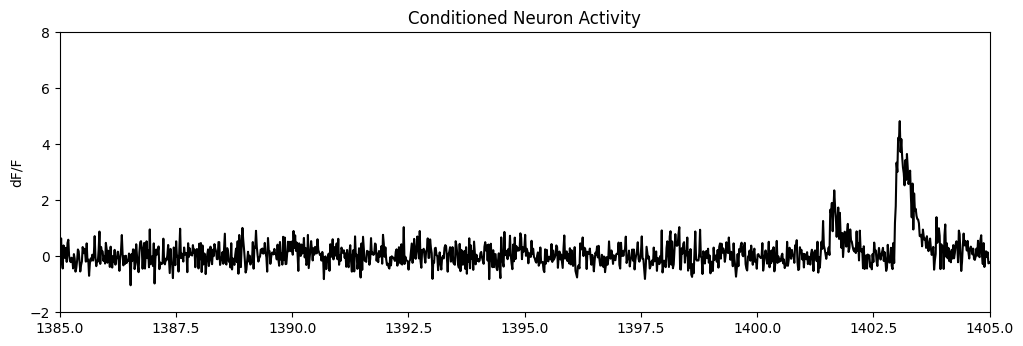

In [21]:
# Plot the activity of the conditioned neuron over a narrow time window 
time_window = [1385, 1405] 

# Set up figure 
plt.figure(figsize=(12, 8))

# Plot dF/F of conditioned neuron 
plt.subplot(2, 1, 1) # Set up subplots - we'll add the behavior events later on 
plt.plot(timestamps, dff[:, cn_index], 
         color='black', 
         label="dF/F")
plt.ylabel("dF/F")
plt.title("Conditioned Neuron Activity")
plt.ylim(-2, 8)
plt.xlim(time_window) # Plot a select sample of trials 


In [22]:
# Convert behavior events reported relative to trial start to absolute time

#create empty lists for the behavior events
lick_times = []
go_cues = []
rewards = []
threshold_crossing_times = []
zaber_step_times = []

#for each trial, add the event times to trial start and append to appropriate list
for index, row in trials.iterrows():
    lick_times.append(row.lick_L[np.isfinite(row.lick_L)] + row.start_time) # use isfinite to filter out nans
    zaber_step_times.append(row.zaber_step_times[np.isfinite(row.zaber_step_times)] + row.start_time)
    rewards.append(row.reward_time + row.start_time)

#reshape lick_times and zaber_step_times (this is needed because there is a list of times for each trial)
lick_times = np.hstack(lick_times)
zaber_step_times = np.hstack(zaber_step_times)


Text(0.5, 1.0, 'Reward times')

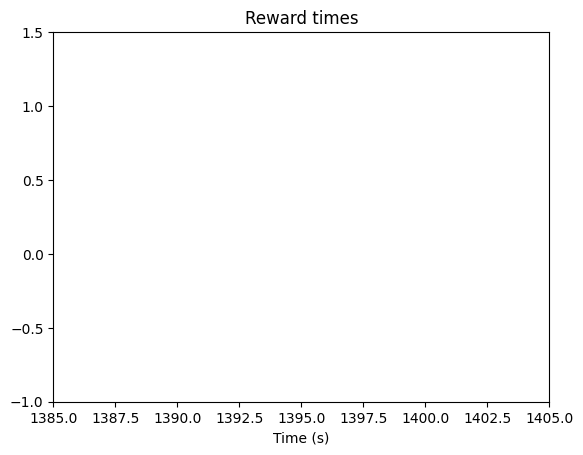

In [23]:
plt.stem(lick_times, np.ones_like(lick_times),
         linefmt='b-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Licks")
plt.xlabel("Time (s)")
plt.xlim(time_window)
plt.ylim(-1, 1.5)
plt.title("Reward times")


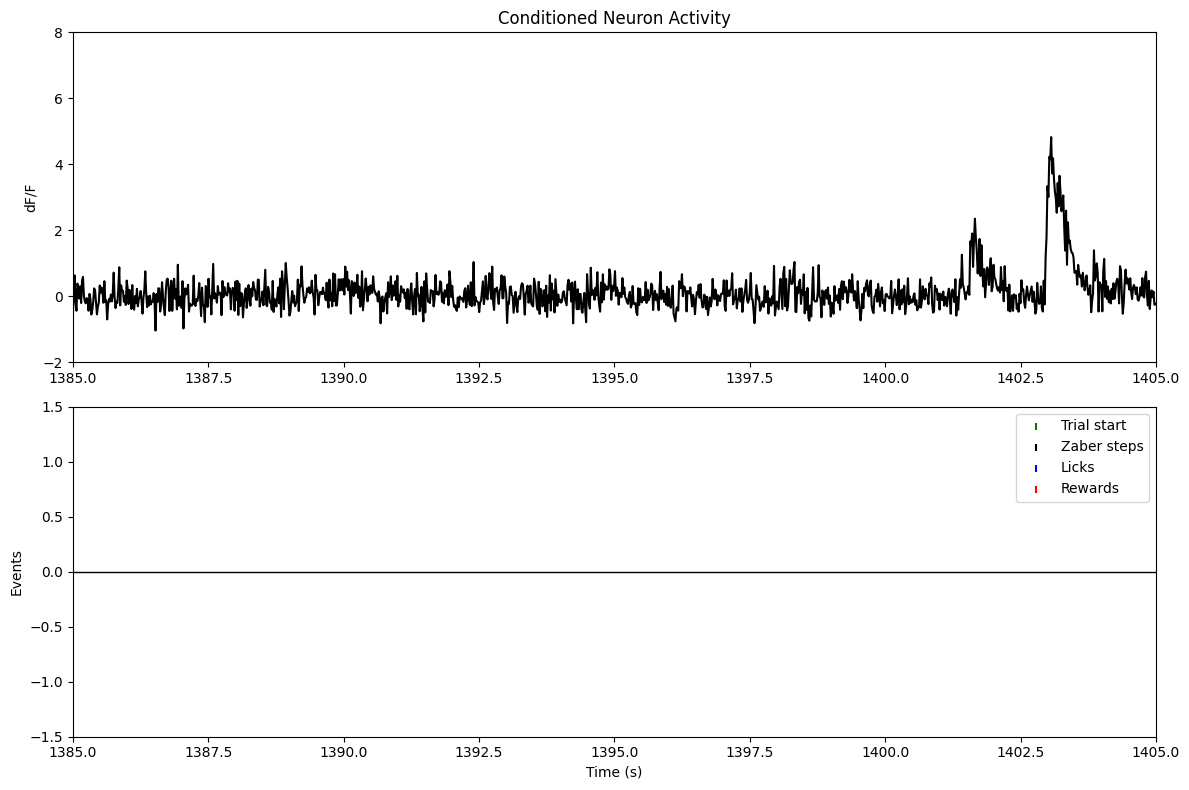

In [24]:
# Set up figure 
plt.figure(figsize=(12, 8))

# Plot dF/F of conditioned neuron 
plt.subplot(2, 1, 1) # Set up subplots - we'll add the behavior events later on 
plt.plot(timestamps, dff[:, cn_index], 
         color='black', 
         label="dF/F")
plt.ylabel("dF/F")
plt.title("Conditioned Neuron Activity")
plt.ylim(-2, 8)
plt.xlim(time_window) # Plot a select sample of trials 

# Plot behavior events using plt.stem 
plt.subplot(2, 1, 2)
plt.stem(trials.start_time.values, -np.ones_like(trials.start_time.values),
         linefmt='g-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Trial start")
plt.stem(zaber_step_times, np.ones_like(zaber_step_times),
         linefmt='k-', 
         markerfmt=' ', 
         basefmt=" ",
         label="Zaber steps")
plt.stem(lick_times, -np.ones_like(lick_times),
         linefmt='b-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Licks")
plt.stem(rewards, -np.ones_like(rewards),
         linefmt='r-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Rewards")
plt.axhline(0, color = 'black', linestyle = '-', linewidth = 1)

plt.xlabel("Time (s)")
plt.ylabel("Events")
plt.ylim(-1.5, 1.5)
plt.xlim(time_window)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



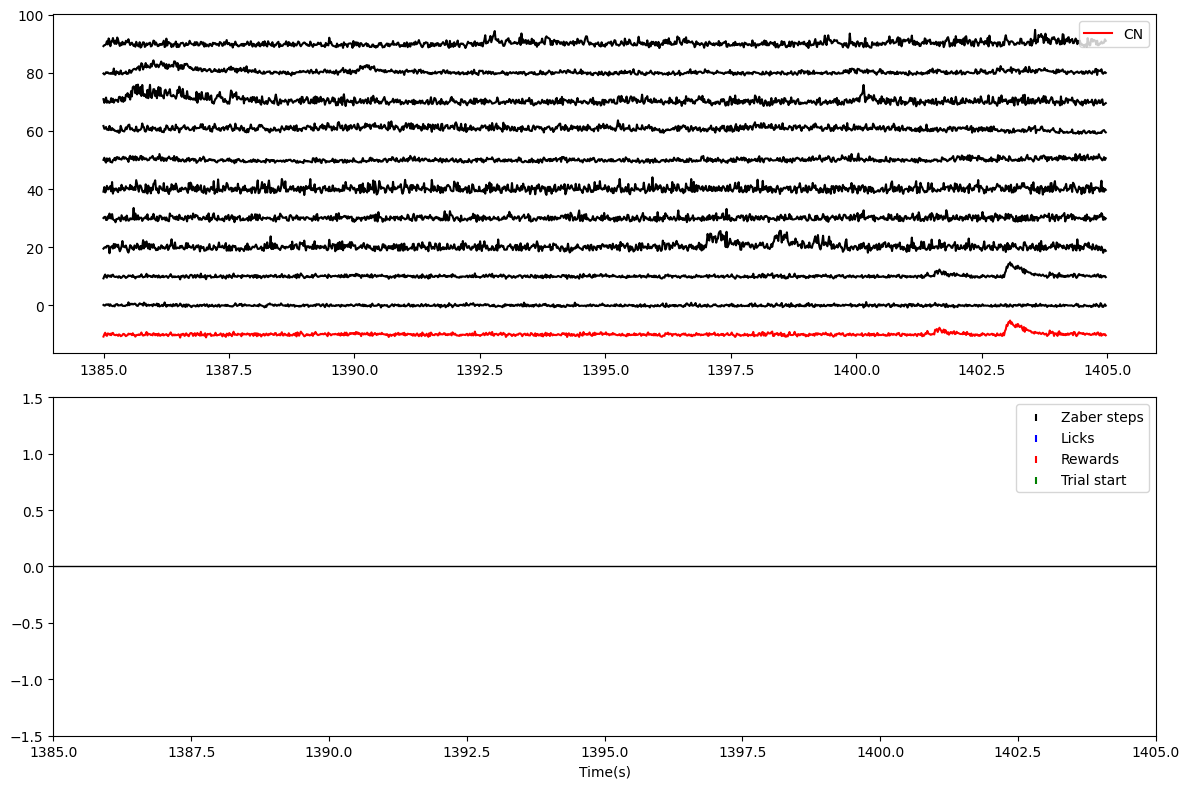

In [25]:
# Initialize Variables 
valid_rois = image_segmentation[image_segmentation.is_soma == 1].index[0:10] # select first 10 valid ROIs to plot 
offset = 10 # y offset for plotting 

# Convert time window to frames 
start_frame = int(time_window[0] * frame_rate)
stop_frame  = int(time_window[1] * frame_rate)

# Slice the frame window out of the filtered_dff_traces array 
subsample_dff = dff[start_frame:stop_frame, :] 

# Set up figure 
plt.figure(figsize=(12, 8))

# Plot other neurons in dff_trace during this time window with an offset 
plt.subplot(2,1,1) 
offset_counter = 0 
for roi in valid_rois:
    plt.plot(timestamps[start_frame:stop_frame], subsample_dff[:, roi]+(offset_counter*offset), 
             color = 'black') 
    offset_counter = offset_counter + 1 

# Plot conditioned neuron 
plt.plot(timestamps[start_frame:stop_frame], subsample_dff[:, cn_index]-offset, 
         color = 'red', 
         label = 'CN')
plt.legend(loc="upper right")

# Plot behavior events 
plt.subplot(2,1,2)
plt.stem(zaber_step_times, np.ones_like(zaber_step_times),
         linefmt='k-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Zaber steps")
plt.stem(lick_times, -np.ones_like(lick_times),
         linefmt='b-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Licks")
plt.stem(rewards, -np.ones_like(rewards),
         linefmt='r-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Rewards")
plt.stem(trials.start_time.values, -np.ones_like(trials.start_time.values),
         linefmt='g-', 
         markerfmt=' ', 
         basefmt=" ", 
         label="Trial start")
plt.axhline(0, 
            color = 'black', 
            linestyle = '-', 
            linewidth = 1)

plt.legend(loc="upper right")
plt.xlim(time_window)
plt.ylim(-1.5, 1.5)
plt.xlabel('Time(s)') 
plt.tight_layout()


Text(0.5, 1.0, 'Pairwise Correlations Between CN and ROI # [0, 2, 4, 7, 10, 11, 15, 17, 18, 21]')

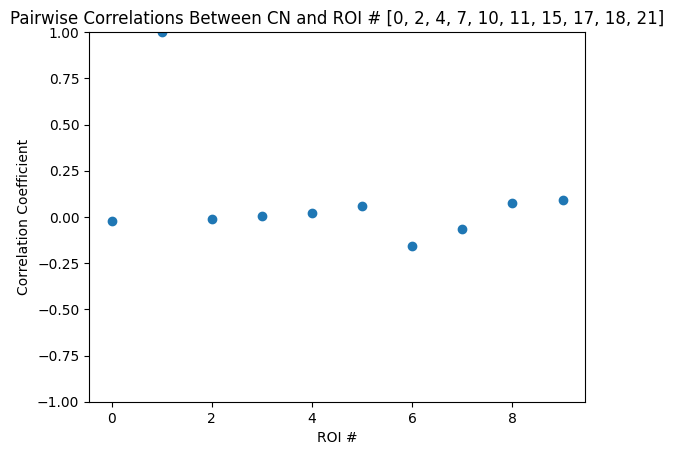

In [26]:
target = subsample_dff[:, cn_index] # Get dff for CN only 
others = subsample_dff[:, valid_rois] # Get dff for other neurons 

# Iteratively compute pairwise correlations between just cn and other select neurons, store each value in an array 
correlations = np.array([pearsonr(target, others[:, i])[0] for i in range(others.shape[1])]) 

# Plot Correlations 
plt.plot(correlations, 'o')
plt.ylim(-1, 1)
plt.xlabel('ROI #') 
plt.ylabel('Correlation Coefficient') 
plt.title(f"Pairwise Correlations Between CN and ROI # {valid_rois.tolist()}")


In [27]:
filtered_roi_table = filter_roi_table(nwbfile) 
cleaned_dff, cleaned_roi_table = filter_dff(nwbfile, filtered_roi_table)


In [28]:

# Get the start and stop frames for the spontaneous epochs from the epoch table

# The spontaneous period before the task consists of the first two spontaneous blocks
spontaneous_pre_start = epoch_table[epoch_table.stimulus_name == 'spont'].start_frame.item()
spontaneous_pre_stop = epoch_table[epoch_table.stimulus_name == 'spont'].stop_frame.item()

# The last spontaneous period is the last spontaneous epoch
spontaneous_post_start = epoch_table[epoch_table.stimulus_name == 'spont_post'].start_frame.item()
spontaneous_post_stop = epoch_table[epoch_table.stimulus_name == 'spont_post'].stop_frame.item()

# Index into the dff traces array for spontaneous epochs 
dff_pre = cleaned_dff[spontaneous_pre_start:spontaneous_pre_stop, :]
print(dff_pre.shape)

dff_post = cleaned_dff[spontaneous_post_start:spontaneous_post_stop, :]
print(dff_post.shape)


(7199, 298)
(13799, 298)


In [29]:
# Compute correlations for spontaneous pre-BCI epoch 
target_pre = dff_pre[:, cn_index]
others_pre = dff_pre[:]
correlations_pre = np.array([pearsonr(target_pre, others_pre[:, i])[0] for i in range(others_pre.shape[1])])

# Compute correlations for spontaneous post-BCI epoch 
target_post = dff_post[:, cn_index]
others_post = dff_post[:]

correlations_post = np.array([pearsonr(target_post, others_post[:, i])[0] for i in range(others_post.shape[1])])


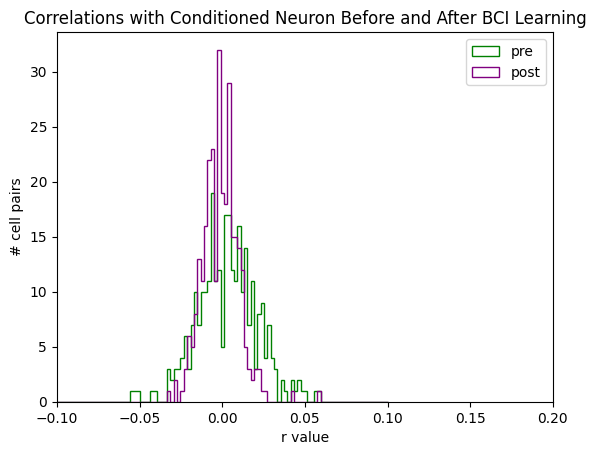

In [30]:
# Plot correlations as a histogram 

# Get conditioned neuron index
cn_index = np.where(image_segmentation.index == trials.closest_roi.unique()[0])[0][0]

# Remove the self-correlation (comparing cn with cn) 
mask = np.arange(len(correlations_pre)) != cn_index
cn_correlations_pre = correlations_pre[mask]
cn_correlations_post = correlations_post[mask]

# Define shared bin edges
bins = np.linspace(-0.1, 0.1, 100)

# Plot histograms
plt.hist(cn_correlations_pre, 
         bins=bins, 
         color='green', 
         label='pre', 
         histtype='step')
plt.hist(cn_correlations_post, 
         bins=bins, 
         color='purple', 
         label='post', 
         histtype='step')

plt.title('Correlations with Conditioned Neuron Before and After BCI Learning')
plt.xlabel('r value')
plt.ylabel('# cell pairs')
plt.xlim(-0.1, 0.2)
plt.legend()


In [31]:
# Calculate the mean of the pre and post distributions

print('mean pre:', cn_correlations_pre.mean())
print('mean post:', cn_correlations_post.mean())

# Run the stats!
t, p_val = stats.ttest_ind(cn_correlations_pre, cn_correlations_post)
print('p_val:', p_val)

# Is this statistically significant? If p-value <0.05, then yes. 


mean pre: 0.0032149886
mean post: -0.00043600707
p_val: 0.014670680722434912


In [32]:
top_k = 10  # number of neurons to track

# exclude CN itself
mask = np.arange(len(correlations_pre)) != cn_index

pre_corr = correlations_pre[mask]
post_corr = correlations_post[mask]

# get indices of top correlated neurons pre-BCI
top_indices = np.argsort(pre_corr)[-top_k:]

In [33]:
top_pre = pre_corr[top_indices]
top_post = post_corr[top_indices]

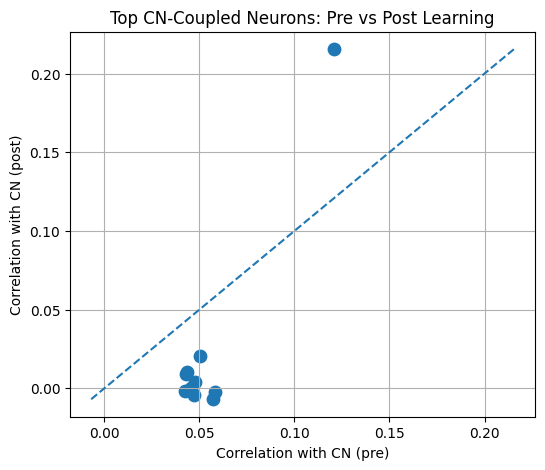

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(top_pre, top_post, s=80)

# diagonal reference
lims = [min(top_pre.min(), top_post.min()),
        max(top_pre.max(), top_post.max())]

plt.plot(lims, lims, '--')

plt.xlabel("Correlation with CN (pre)")
plt.ylabel("Correlation with CN (post)")
plt.title("Top CN-Coupled Neurons: Pre vs Post Learning")

plt.grid(True)
plt.show()

In [35]:
import numpy as np

x_positions = []
y_positions = []

for mask in cleaned_roi_table["image_mask"]:
    
    coords = np.argwhere(mask)   # pixels belonging to the neuron
    
    y_mean, x_mean = coords.mean(axis=0)  # center
    
    x_positions.append(x_mean)
    y_positions.append(y_mean)

x_positions = np.array(x_positions)
y_positions = np.array(y_positions)

In [36]:
cn_x = trials.conditioned_neuron_x.iloc[0]
cn_y = trials.conditioned_neuron_y.iloc[0]

In [37]:
distances = np.sqrt((x_positions - cn_x)**2 + (y_positions - cn_y)**2)

In [38]:
delta_r = correlations_post - correlations_pre

mask = np.arange(len(delta_r)) != cn_index

distances = distances[mask]
delta_r = delta_r[mask]

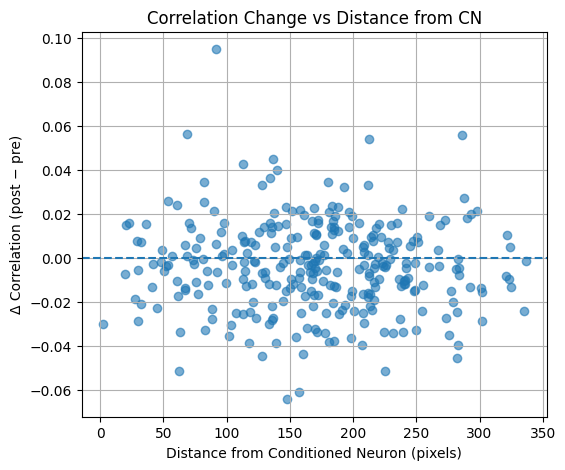

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(distances, delta_r, alpha=0.6)

plt.axhline(0, linestyle='--')

plt.xlabel("Distance from Conditioned Neuron (pixels)")
plt.ylabel("Δ Correlation (post − pre)")
plt.title("Correlation Change vs Distance from CN")

plt.grid(True)
plt.show()

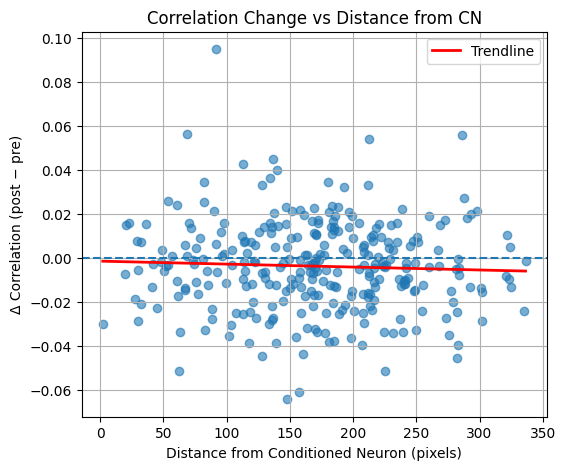

Slope: -1.3359249754111759e-05
Correlation (r): -0.04693535734535072
p-value: 0.4202990100574048


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(distances, delta_r)

# create regression line
x_line = np.linspace(distances.min(), distances.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(6,5))

plt.scatter(distances, delta_r, alpha=0.6)

# regression line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Trendline")

plt.axhline(0, linestyle="--")

plt.xlabel("Distance from Conditioned Neuron (pixels)")
plt.ylabel("Δ Correlation (post − pre)")
plt.title("Correlation Change vs Distance from CN")

plt.legend()

plt.grid(True)
plt.show()

print("Slope:", slope)
print("Correlation (r):", r_value)
print("p-value:", p_value)

In [51]:
def plot_cn_behavior(subject_id, session_index=0, time_window=None):
    mouse_sessions = metadata[metadata['subject_id'] == subject_id].sort_values(by='session_number')
    session_name = mouse_sessions.name.values[session_index]

    session_dir = os.path.join('/data/', 'brain-computer-interface-v2', session_name)
    nwb_file = [f for f in os.listdir(session_dir) if 'nwb' in f][0]
    nwb_path = os.path.join(session_dir, nwb_file)

    with NWBZarrIO(str(nwb_path), 'r') as io:
        nwbfile = io.read()

    trials = nwbfile.stimulus["Trials"].to_dataframe()
    dff = nwbfile.processing["processed"].data_interfaces["dff"].roi_response_series["dff"].data

    frame_rate = nwbfile.imaging_planes["processed"].imaging_rate
    time_step = 1 / frame_rate
    n_frames = dff.shape[0]
    timestamps = np.linspace(0, time_step * n_frames, num=n_frames)

    cn_index = trials.closest_roi.unique()[0]
    cn_trace = dff[:, cn_index]

    lick_times = []
    zaber_step_times = []
    rewards = []

    for _, row in trials.iterrows():
        lick_times.append(row.lick_L[np.isfinite(row.lick_L)] + row.start_time)
        zaber_step_times.append(row.zaber_step_times[np.isfinite(row.zaber_step_times)] + row.start_time)
        rewards.append(row.reward_time + row.start_time)

    lick_times = np.hstack(lick_times)
    zaber_step_times = np.hstack(zaber_step_times)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(timestamps, cn_trace, color='black')
    low = np.percentile(cn_trace, 1)
    high = np.percentile(cn_trace, 99)
    plt.ylim(low, high)
    plt.ylabel("dF/F")
    plt.title(f"Subject {subject_id} — Conditioned Neuron Activity")
    if time_window is not None:
        plt.xlim(time_window)

    plt.subplot(2, 1, 2)
    plt.stem(trials.start_time.values, -np.ones_like(trials.start_time.values),
             linefmt='g-', markerfmt=' ', basefmt=" ", label="Trial start")
    plt.stem(zaber_step_times, np.ones_like(zaber_step_times),
             linefmt='k-', markerfmt=' ', basefmt=" ", label="Zaber steps")
    plt.stem(lick_times, -np.ones_like(lick_times),
             linefmt='b-', markerfmt=' ', basefmt=" ", label="Licks")
    plt.stem(rewards, -np.ones_like(rewards),
             linefmt='r-', markerfmt=' ', basefmt=" ", label="Rewards")
    plt.axhline(0, color='black')

    if time_window is not None:
        plt.xlim(time_window)

    plt.xlabel("Time (s)")
    plt.ylabel("Events")
    plt.legend()
    plt.tight_layout()
    plt.show()

/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


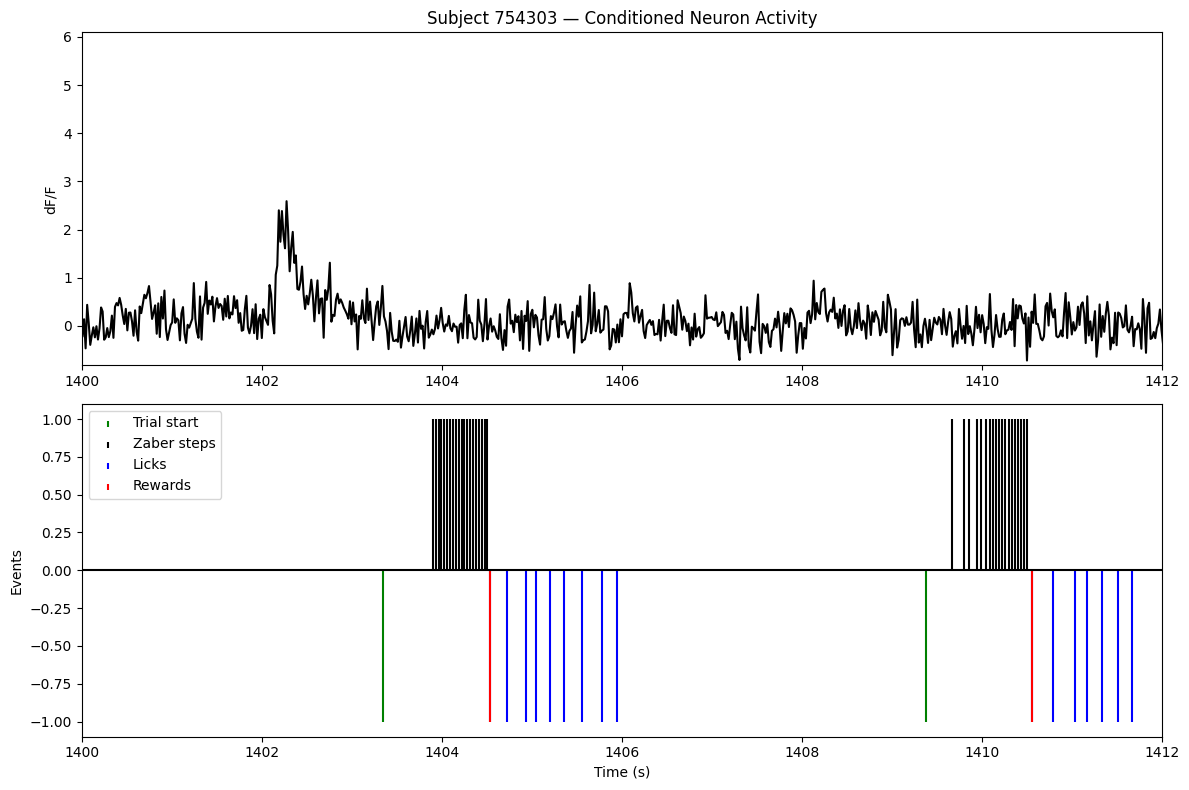

In [ ]:
plot_cn_behavior(754303, session_index=0, time_window=[1415, 1407])